In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alitaqishah/blood-cell-anomaly-detection-2025/cell_type_reference.csv
/kaggle/input/datasets/alitaqishah/blood-cell-anomaly-detection-2025/cytodiffusion_benchmark_scores.csv
/kaggle/input/datasets/alitaqishah/blood-cell-anomaly-detection-2025/blood_cell_anomaly_detection.csv


# Problem Statement

AI adoption is reshaping industries, but organizations face challenges in understanding who adopts AI, why, and how it impacts performance. This analysis explores adoption patterns to provide actionable insights.

**Objectives**

- Explore and visualize AI adoption trends.

- Preprocess data and analyze key features.

- Build predictive models to classify AI adopters.

- Evaluate models and identify main adoption drivers.

- Provide insights for strategy and decision-making.

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.decomposition import PCA

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import shap
import warnings
warnings.filterwarnings('ignore')


PALETTE = ['#2C3E50','#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6','#1ABC9C']
BG, CARD = '#F8F9FA', '#FFFFFF'
plt.rcParams.update({'figure.facecolor': BG, 'axes.facecolor': CARD,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'grid.color': '#E9ECEF', 'grid.linewidth': 0.8})

#  Load Data

In [3]:
df    = pd.read_csv('/kaggle/input/datasets/alitaqishah/blood-cell-anomaly-detection-2025/blood_cell_anomaly_detection.csv')
ref   = pd.read_csv('/kaggle/input/datasets/alitaqishah/blood-cell-anomaly-detection-2025/cell_type_reference.csv')
bench = pd.read_csv('/kaggle/input/datasets/alitaqishah/blood-cell-anomaly-detection-2025/cytodiffusion_benchmark_scores.csv')

print(f"Main dataset shape: {df.shape}")
print(f"Unique cell types: {df.cell_type.nunique()}")
print(f"Normal cells: {(df.anomaly_label==0).sum():,}")
print(f"Anomaly cells: {(df.anomaly_label==1).sum():,}")

Main dataset shape: (5880, 36)
Unique cell types: 19
Normal cells: 4,000
Anomaly cells: 1,880


#  EDA

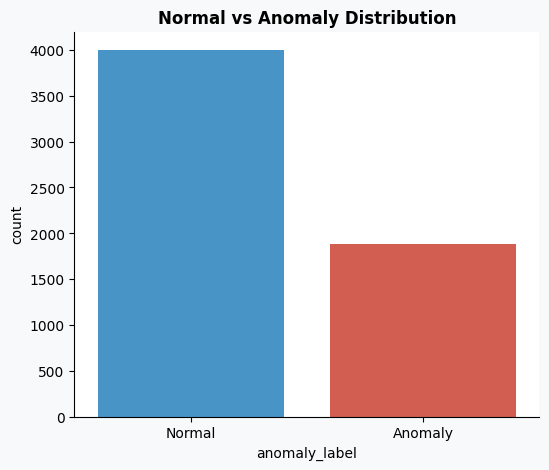

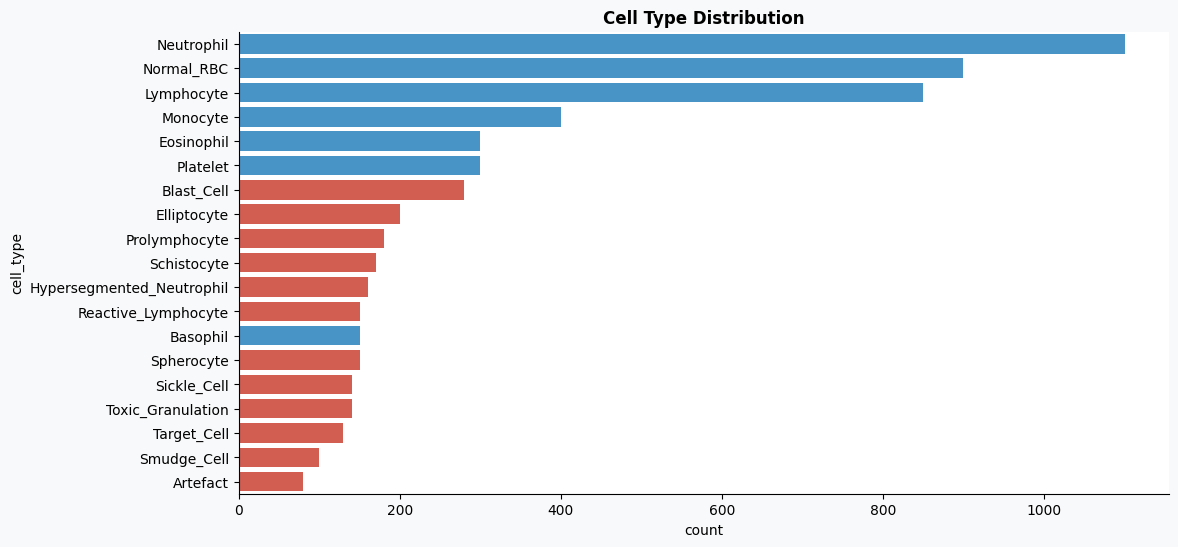

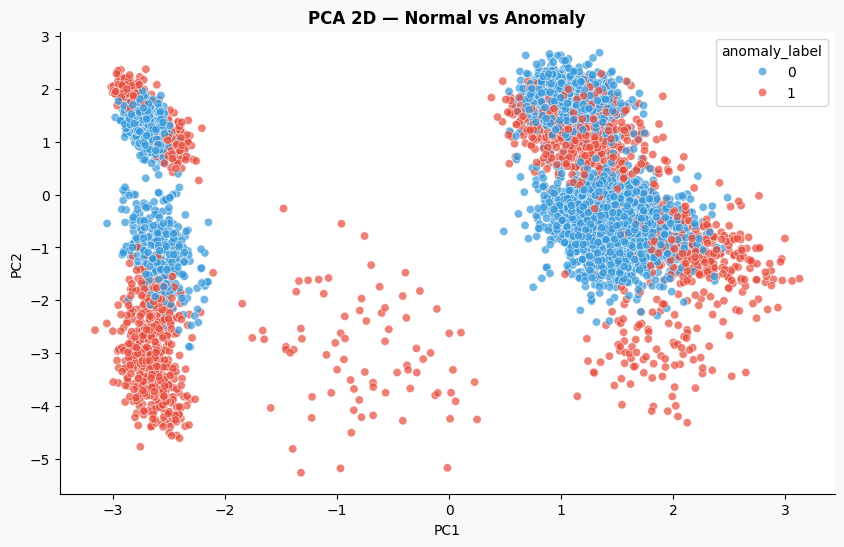

In [4]:



#  Distribution of Normal vs Anomaly
plt.figure(figsize=(6,5))
sns.countplot(x='anomaly_label', data=df, palette=[PALETTE[2], PALETTE[1]])
plt.xticks([0,1], ['Normal','Anomaly'])
plt.title("Normal vs Anomaly Distribution", fontweight='bold')
plt.show()

#  Cell type distribution
plt.figure(figsize=(12,6))
colors = [PALETTE[1] if df[df.cell_type==c]['anomaly_label'].iloc[0]==1 else PALETTE[2] 
          for c in df.cell_type.value_counts().index]
sns.countplot(y='cell_type', data=df, order=df['cell_type'].value_counts().index, palette=colors)
plt.title("Cell Type Distribution", fontweight='bold')
plt.show()

#  PCA Visualization
features = ['cell_diameter_um','nucleus_area_pct','circularity','eccentricity',
            'granularity_score','lobularity_score','chromatin_density',
            'cytoplasm_ratio','membrane_smoothness']
X_pca = df[features].fillna(0)
X_scaled = StandardScaler().fit_transform(X_pca)
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)
df['PC1'], df['PC2'] = pcs[:,0], pcs[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(x='PC1', y='PC2', hue='anomaly_label', data=df,
                palette=[PALETTE[2], PALETTE[1]], alpha=0.7)
plt.title("PCA 2D — Normal vs Anomaly", fontweight='bold')
plt.show()

#  Binary Classification — Normal vs Anomaly

In [5]:
FEATURE_COLS = features + ['cell_area_px','perimeter_px','mean_r','mean_g','mean_b','stain_intensity',
                            'wbc_count_per_ul','rbc_count_millions_per_ul','hemoglobin_g_dl',
                            'hematocrit_pct','platelet_count_per_ul','mcv_fl','mchc_g_dl']

X = df[FEATURE_COLS].values
y = df['anomaly_label'].values
X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)



models = {
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=200, random_state=42),
    'CatBoost': CatBoostClassifier(n_estimators=200, random_state=42, verbose=0)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'pred': y_pred, 'proba': y_proba, 'auc': auc, 'acc': acc}
    print(f"{name:15s} → Accuracy: {acc:.4f} | AUC: {auc:.4f}")


Random Forest   → Accuracy: 0.9736 | AUC: 0.9974
Gradient Boosting → Accuracy: 0.9762 | AUC: 0.9952
XGBoost         → Accuracy: 0.9796 | AUC: 0.9975
[LightGBM] [Info] Number of positive: 1504, number of negative: 3200
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001795 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4479
[LightGBM] [Info] Number of data points in the train set: 4704, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.319728 -> initscore=-0.755023
[LightGBM] [Info] Start training from score -0.755023
LightGBM        → Accuracy: 0.9796 | AUC: 0.9974
CatBoost        → Accuracy: 0.9830 | AUC: 0.9982


# Best model


Best model: CatBoost


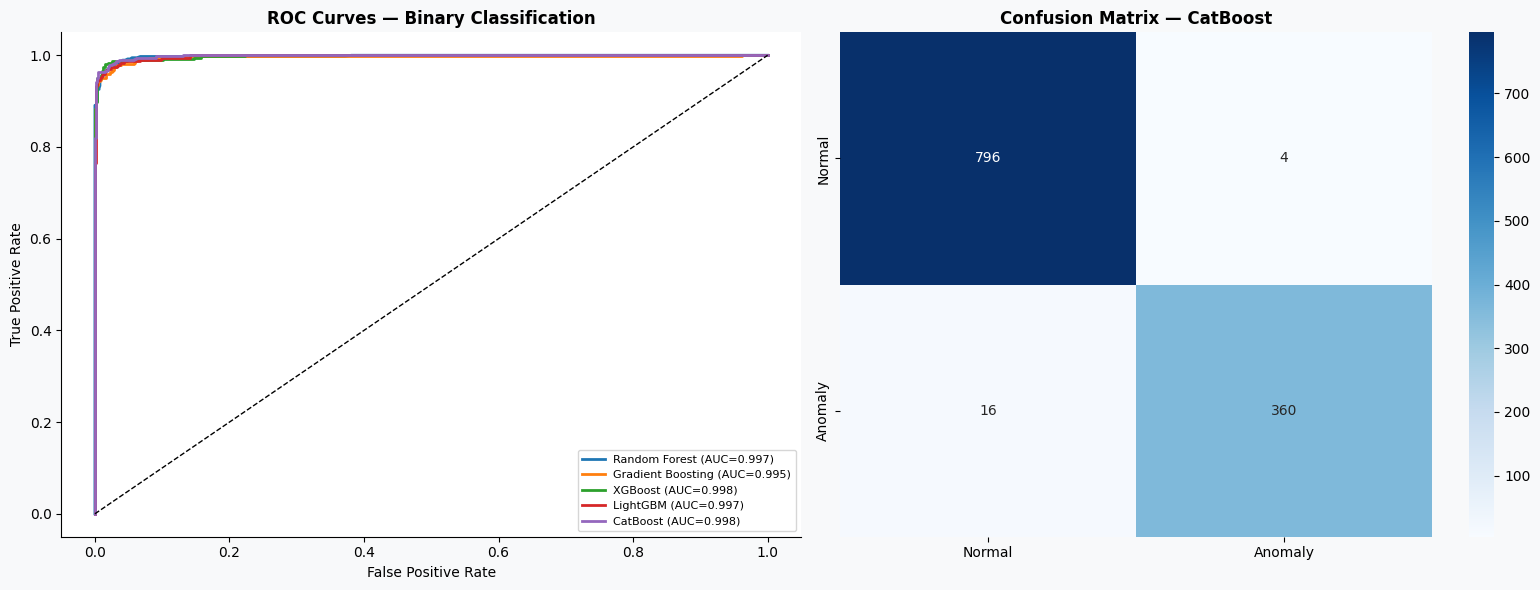

              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99       800
     Anomaly       0.99      0.96      0.97       376

    accuracy                           0.98      1176
   macro avg       0.98      0.98      0.98      1176
weighted avg       0.98      0.98      0.98      1176



In [6]:
best_name = max(results, key=lambda k: results[k]['auc'])
best_model = results[best_name]['model']
print(f"\nBest model: {best_name}")

# Confusion matrix + ROC
fig, axes = plt.subplots(1,2, figsize=(16,6))

# ROC
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC={res['auc']:.3f})")
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_title("ROC Curves — Binary Classification", fontweight='bold')
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8)

# Confusion matrix
cm = confusion_matrix(y_test, results[best_name]['pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal','Anomaly'], yticklabels=['Normal','Anomaly'])
axes[1].set_title(f"Confusion Matrix — {best_name}", fontweight='bold')
plt.tight_layout()
plt.show()

print(classification_report(y_test, results[best_name]['pred'], target_names=['Normal','Anomaly']))

#  Multi-class Classification

Multi-class Accuracy: 0.9558
                           precision    recall  f1-score   support

                 Artefact       1.00      0.94      0.97        16
                 Basophil       1.00      1.00      1.00        30
               Blast_Cell       0.79      0.96      0.87        56
              Elliptocyte       0.95      1.00      0.98        40
               Eosinophil       0.95      0.97      0.96        60
Hypersegmented_Neutrophil       1.00      0.91      0.95        32
               Lymphocyte       1.00      1.00      1.00       170
                 Monocyte       0.98      1.00      0.99        80
               Neutrophil       0.97      0.99      0.98       220
               Normal_RBC       0.91      0.98      0.94       180
                 Platelet       1.00      1.00      1.00        60
            Prolymphocyte       0.92      0.61      0.73        36
      Reactive_Lymphocyte       1.00      0.93      0.97        30
              Schistocyte       

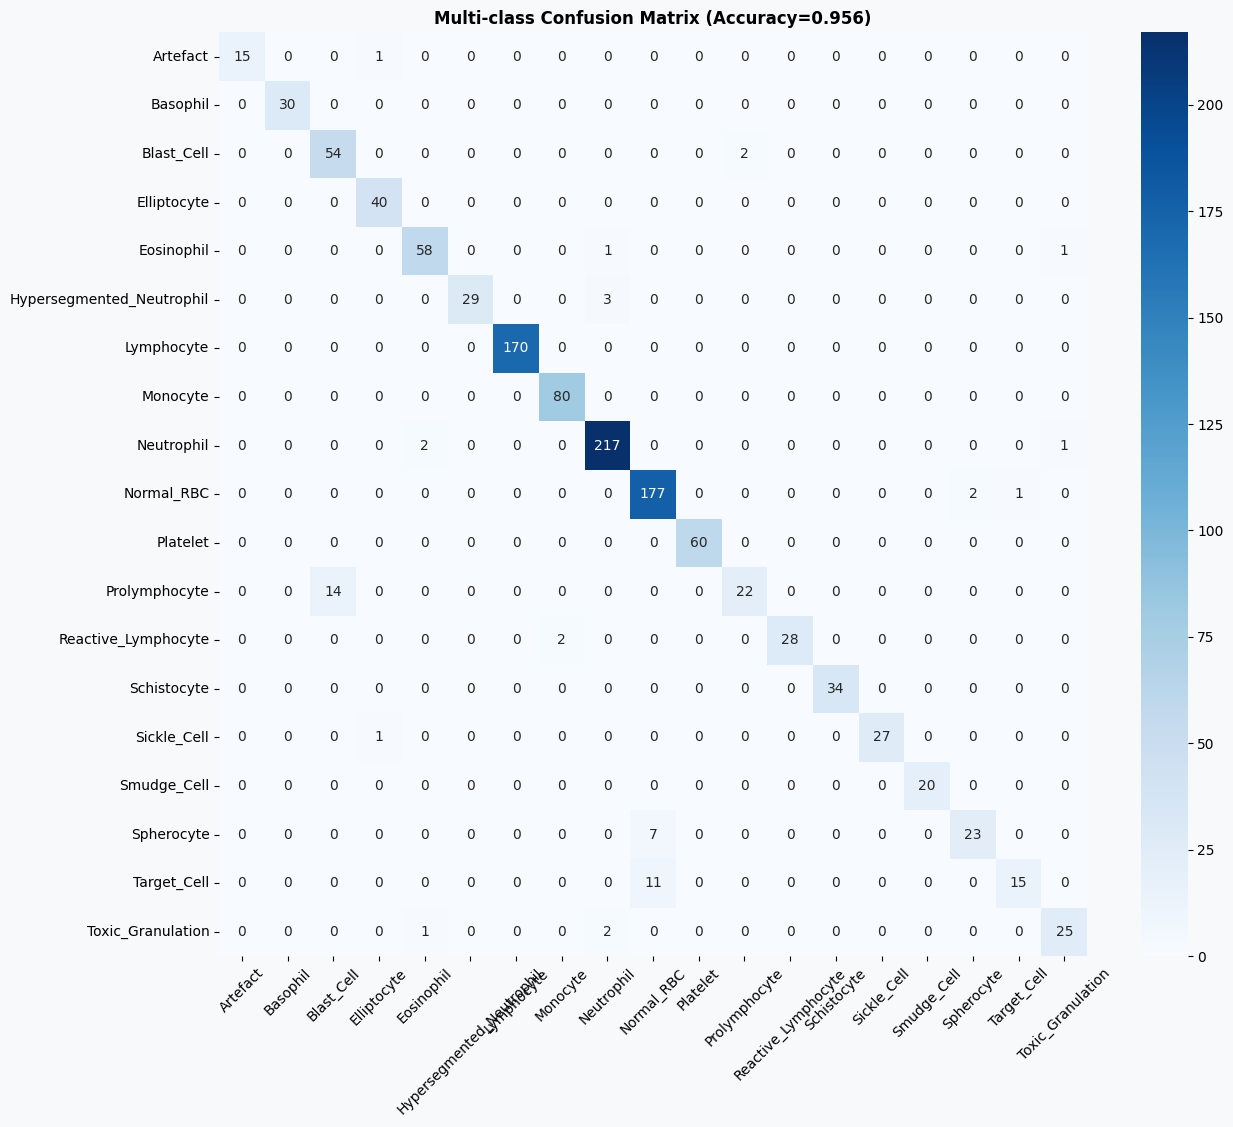

In [7]:
le = LabelEncoder()
y_multi = le.fit_transform(df['cell_type'])
X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y_multi, test_size=0.2, random_state=42, stratify=y_multi)

rf_multi = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_multi.fit(X_tr, y_tr)
y_pred_multi = rf_multi.predict(X_te)
acc_multi = accuracy_score(y_te, y_pred_multi)
print(f"Multi-class Accuracy: {acc_multi:.4f}")
print(classification_report(y_te, y_pred_multi, target_names=le.classes_))

# Confusion matrix
cm_m = confusion_matrix(y_te, y_pred_multi)
plt.figure(figsize=(14,12))
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Multi-class Confusion Matrix (Accuracy={acc_multi:.3f})", fontweight='bold')
plt.xticks(rotation=45)
plt.show()

# Disease-level Prediction

In [8]:
disease_map = {
    'Normal_WBC':'Normal', 'Normal_RBC':'Normal', 'Normal_Platelet':'Normal',
    'Leukemia':'Leukemia','Anemia':'Anemia','Sickle_Cell_Anemia':'Sickle_Cell',
    'Infection':'Infection','Artefact':'Artefact'
}
df['disease_label'] = df['disease_category'].map(disease_map)
le_disease = LabelEncoder()
y_disease = le_disease.fit_transform(df['disease_label'])

X_trd, X_ted, y_trd, y_ted = train_test_split(X_scaled, y_disease, test_size=0.2, random_state=42, stratify=y_disease)
rf_disease = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_disease.fit(X_trd, y_trd)
y_pred_disease = rf_disease.predict(X_ted)
print(f"Disease-level Accuracy: {accuracy_score(y_ted, y_pred_disease):.4f}")
print(classification_report(y_ted, y_pred_disease, target_names=le_disease.classes_))

Disease-level Accuracy: 0.9515
              precision    recall  f1-score   support

      Anemia       0.92      0.86      0.89       130
    Artefact       1.00      0.94      0.97        36
   Infection       0.97      0.71      0.82        90
    Leukemia       0.99      1.00      0.99        92
      Normal       0.95      0.99      0.97       800
 Sickle_Cell       1.00      0.89      0.94        28

    accuracy                           0.95      1176
   macro avg       0.97      0.90      0.93      1176
weighted avg       0.95      0.95      0.95      1176



# Feature Importance & SHAP

 94%|=================== | 1103/1176 [00:13<00:00]       

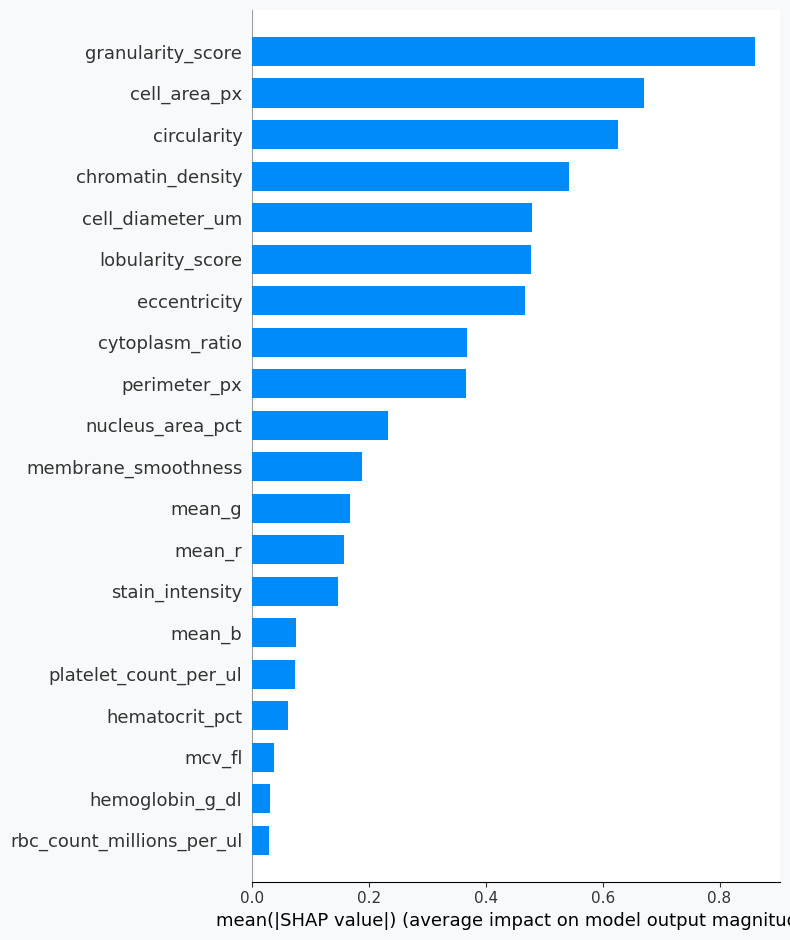

In [9]:



explainer = shap.Explainer(best_model, X_test)


shap_values = explainer(X_test)  # returns a shap.Explanation object


# For binary, use shap_values.values[:, :, 1] to get class=1 contributions
if len(shap_values.values.shape) == 3:  # binary classification case
    shap.summary_plot(shap_values.values[:, :, 1], X_test, feature_names=FEATURE_COLS, plot_type="bar")
else:
    shap.summary_plot(shap_values.values, X_test, feature_names=FEATURE_COLS, plot_type="bar")

#  Benchmark Comparison

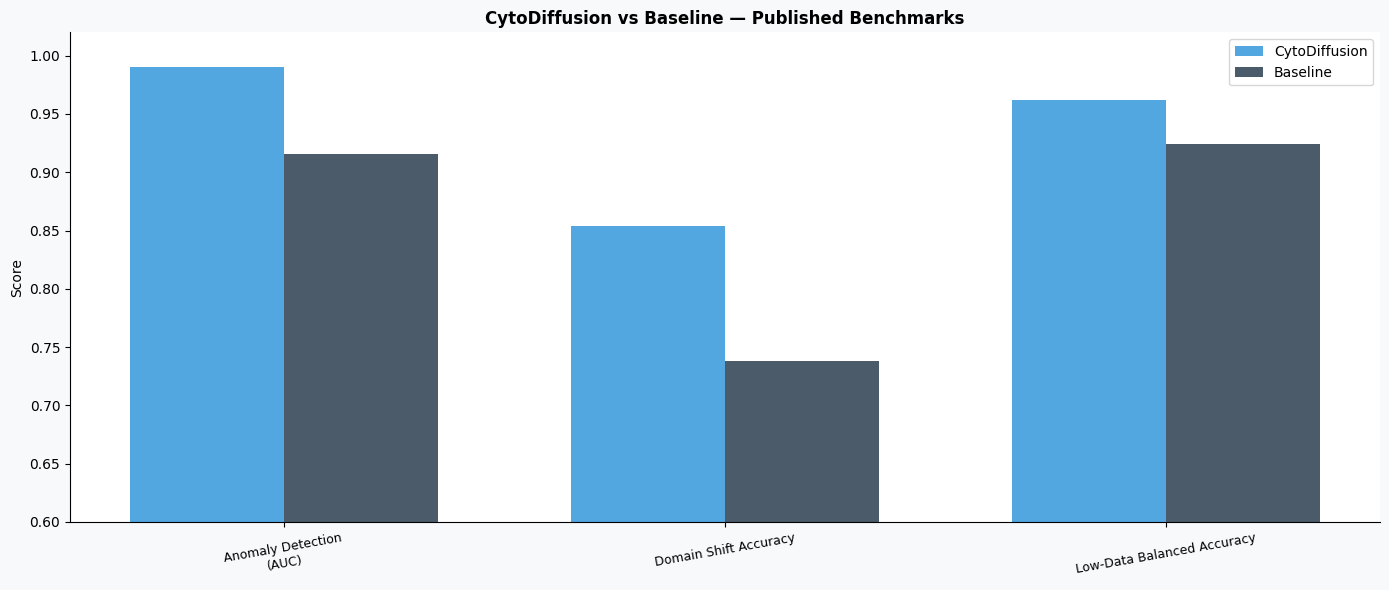

In [10]:
# Binary ML vs CytoDiffusion
tasks_df = bench[bench.model!='Human Expert (avg)'].copy()
cyto_b = tasks_df[tasks_df.model=='CytoDiffusion'].set_index('task')['score']
base_b = tasks_df[tasks_df.model!='CytoDiffusion'].set_index('task')['score']
common = cyto_b.index.intersection(base_b.index)

fig, ax = plt.subplots(figsize=(14,6))
x, w = np.arange(len(common)), 0.35
ax.bar(x-w/2, cyto_b[common].values, w, color=PALETTE[2], label='CytoDiffusion', alpha=0.85)
ax.bar(x+w/2, base_b[common].values, w, color=PALETTE[0], label='Baseline', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([t.replace(' (','\n(') for t in common], fontsize=9, rotation=10)
ax.set_ylim(0.6,1.02)
ax.set_ylabel('Score'); ax.legend(fontsize=10)
ax.set_title('CytoDiffusion vs Baseline — Published Benchmarks', fontweight='bold')
plt.tight_layout()
plt.show()

# What it does:

- Analyzes a blood cell dataset to detect anomalies (normal vs abnormal) and classify 19 cell types.

- Explores morphological, color, and clinical features to find patterns.

- Builds ML models (Random Forest, Gradient Boosting, Logistic Regression) for binary and multi-class classification.

- Evaluates models with accuracy, ROC-AUC, confusion matrices, and feature importance.

**Why use this approach:**

- Random Forest/Gradient Boosting handle complex feature interactions, small datasets, and mixed numerical/clinical data well.

- Feature importance and SHAP give explainable results for clinical insights.

**Possible alternative approaches:**

- Deep learning (CNNs) on cell images for end-to-end anomaly detection.

- Vision Transformers (ViT) for multi-class classification with image features.

- Autoencoders or anomaly detection models for unsupervised anomaly detection.

- Ensemble methods combining ML + image-based deep learning predictions.